In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose as sd
from statsmodels.tsa.stattools import adfuller as adf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

from prophet import Prophet

from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import root_mean_squared_error as rmse

import warnings
warnings.filterwarnings('ignore')

import copy

import plotly.offline as py
import plotly.graph_objects as go

# 1 Basic

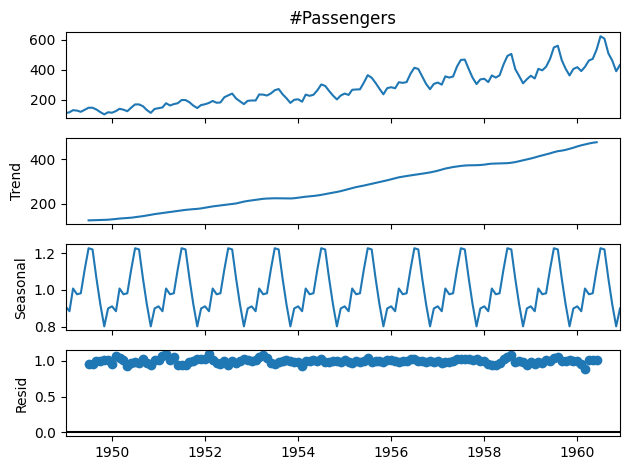

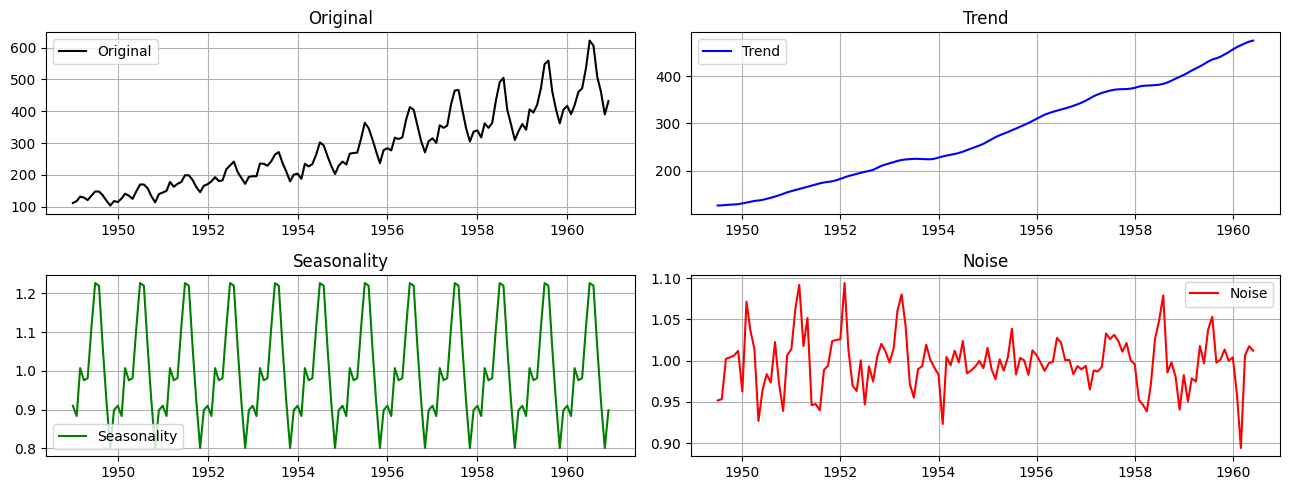

Statistic : 0.8153688792060482
P-Value : 0.991880243437641
No of Lags : 13
Number Of Observation : 130
Critical Values : {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC : 996.692930839019


In [46]:
# Data
data = pd.read_csv(r"E:\DATA FOR TEST\AirPassengers.csv",
                  index_col='Month',
                  parse_dates=['Month'],
                  date_format='%Y-%m')
df = copy.deepcopy(data)

# Seasonality 
raw_data_seasonality = sd(df['#Passengers'], model='multiplicative')
raw_data_seasonality.plot()

Original = df['#Passengers']
Trend = raw_data_seasonality.trend
Noise = raw_data_seasonality.resid
Seasonality = raw_data_seasonality.seasonal

fig, axes = plt.subplots(2, 2, figsize=(13, 5))

axes[0,0].plot(Original, label='Original', color='black')
axes[0,0].grid(True)
axes[0,0].set_title('Original')
axes[0,0].legend(loc='best')

axes[0,1].plot(Trend, label='Trend', color='blue')
axes[0,1].grid(True)
axes[0,1].set_title('Trend')
axes[0,1].legend(loc='best')

axes[1,0].plot(Seasonality, label='Seasonality', color='green')
axes[1,0].grid(True)
axes[1,0].set_title('Seasonality')
axes[1,0].legend(loc='best')

axes[1,1].plot(Noise, label='Noise', color='red')
axes[1,1].grid(True)
axes[1,1].set_title('Noise')
axes[1,1].legend(loc='best')

plt.tight_layout()

plt.show()

# Test ADF
Names = ['Statistic', 'P-Value', 'No of Lags', 'Number Of Observation', 'Critical Values', 'AIC']

raw_adf = adf(df['#Passengers'])

for name, result in zip(Names, raw_adf):
    print(f'{name} : {result}')


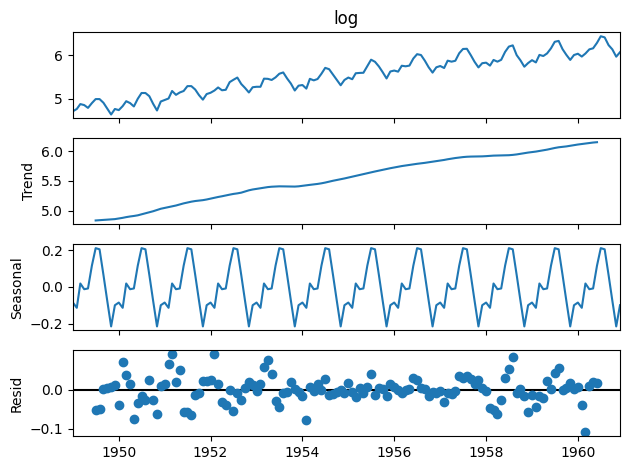

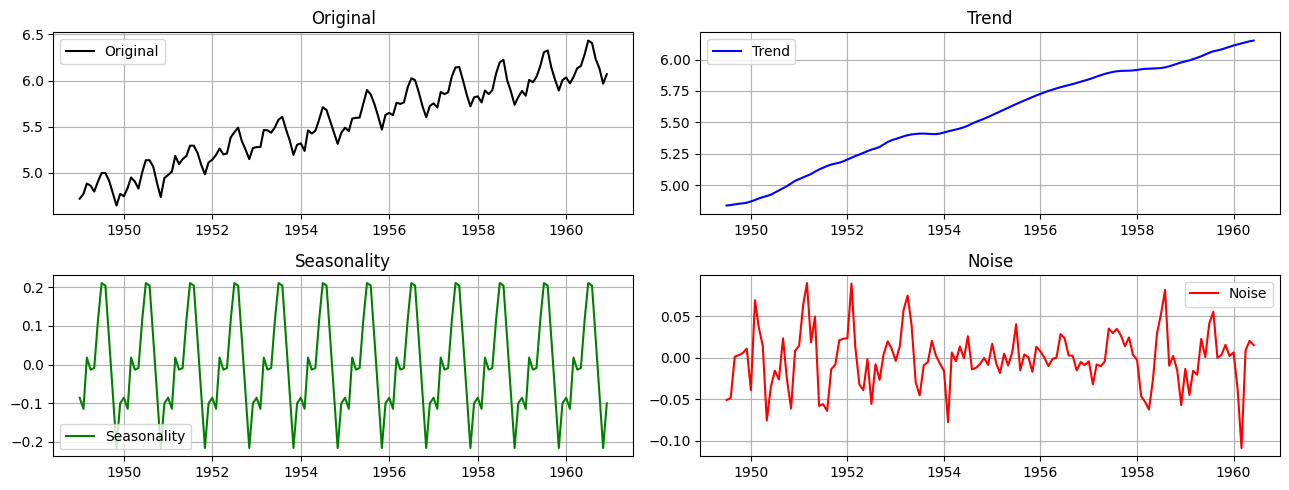

Statistic : -1.7170170891069607
P-Value : 0.42236677477039125
No of Lags : 13
Number Of Observation : 130
Critical Values : {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC : -445.3990312497209


In [50]:
df['log'] = np.log(df['#Passengers'])

# Seasonality 
raw_data_seasonality = sd(df['log'], model='addictive')
raw_data_seasonality.plot()

Original = df['log']
Trend = raw_data_seasonality.trend
Noise = raw_data_seasonality.resid
Seasonality = raw_data_seasonality.seasonal

fig, axes = plt.subplots(2, 2, figsize=(13, 5))

axes[0,0].plot(Original, label='Original', color='black')
axes[0,0].grid(True)
axes[0,0].set_title('Original')
axes[0,0].legend(loc='best')

axes[0,1].plot(Trend, label='Trend', color='blue')
axes[0,1].grid(True)
axes[0,1].set_title('Trend')
axes[0,1].legend(loc='best')

axes[1,0].plot(Seasonality, label='Seasonality', color='green')
axes[1,0].grid(True)
axes[1,0].set_title('Seasonality')
axes[1,0].legend(loc='best')

axes[1,1].plot(Noise, label='Noise', color='red')
axes[1,1].grid(True)
axes[1,1].set_title('Noise')
axes[1,1].legend(loc='best')

plt.tight_layout()

plt.show()

# Test ADF
Names = ['Statistic', 'P-Value', 'No of Lags', 'Number Of Observation', 'Critical Values', 'AIC']

raw_adf = adf(df['log'])

for name, result in zip(Names, raw_adf):
    print(f'{name} : {result}')


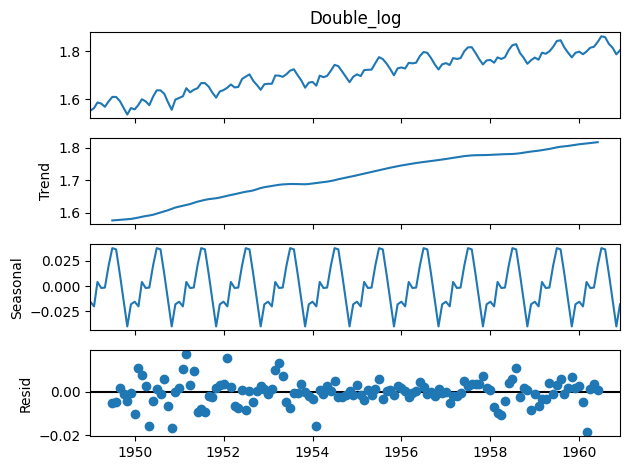

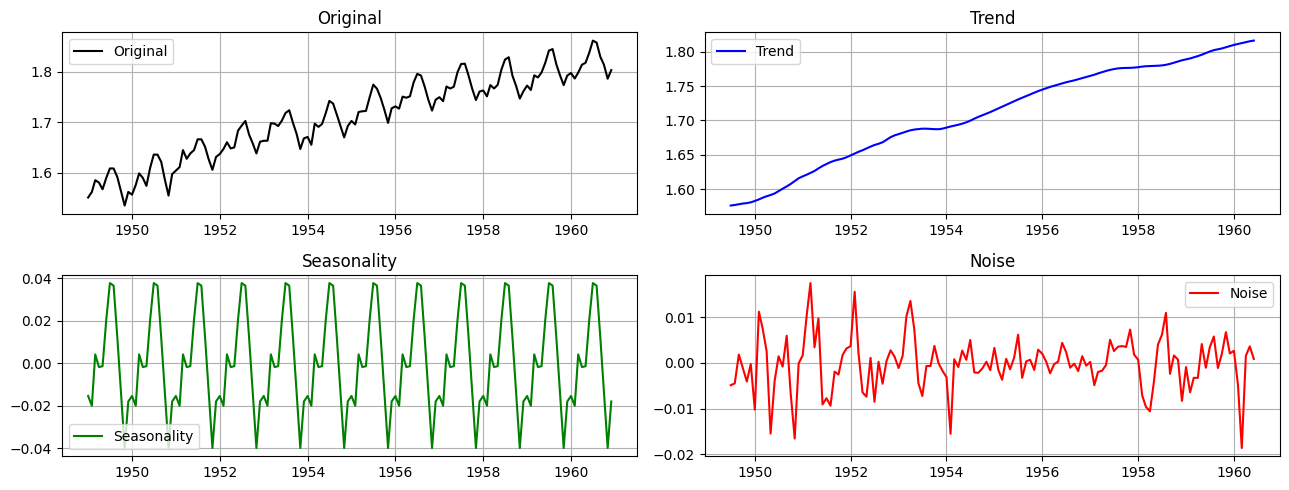

Statistic : -2.156027907005565
P-Value : 0.22258989117061473
No of Lags : 13
Number Of Observation : 130
Critical Values : {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC : -879.8116466202985


In [51]:
df['Double_log'] = np.log(df['log'].values)

# Seasonality 
raw_data_seasonality = sd(df['Double_log'], model='addictive')
raw_data_seasonality.plot()

Original = df['Double_log']
Trend = raw_data_seasonality.trend
Noise = raw_data_seasonality.resid
Seasonality = raw_data_seasonality.seasonal

fig, axes = plt.subplots(2, 2, figsize=(13, 5))

axes[0,0].plot(Original, label='Original', color='black')
axes[0,0].grid(True)
axes[0,0].set_title('Original')
axes[0,0].legend(loc='best')

axes[0,1].plot(Trend, label='Trend', color='blue')
axes[0,1].grid(True)
axes[0,1].set_title('Trend')
axes[0,1].legend(loc='best')

axes[1,0].plot(Seasonality, label='Seasonality', color='green')
axes[1,0].grid(True)
axes[1,0].set_title('Seasonality')
axes[1,0].legend(loc='best')

axes[1,1].plot(Noise, label='Noise', color='red')
axes[1,1].grid(True)
axes[1,1].set_title('Noise')
axes[1,1].legend(loc='best')

plt.tight_layout()

plt.show()

# Test ADF
Names = ['Statistic', 'P-Value', 'No of Lags', 'Number Of Observation', 'Critical Values', 'AIC']

raw_adf = adf(df['Double_log'])

for name, result in zip(Names, raw_adf):
    print(f'{name} : {result}')


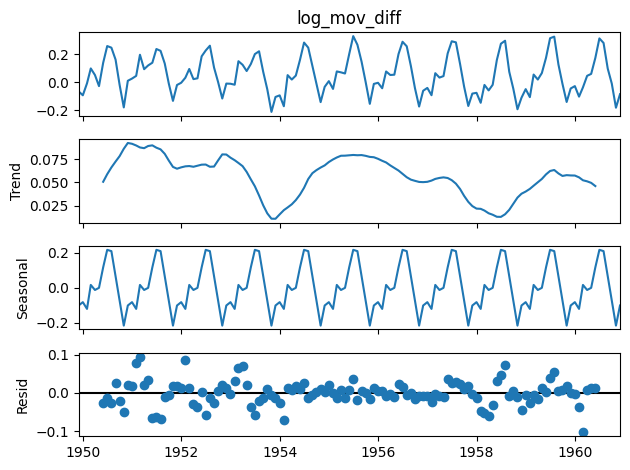

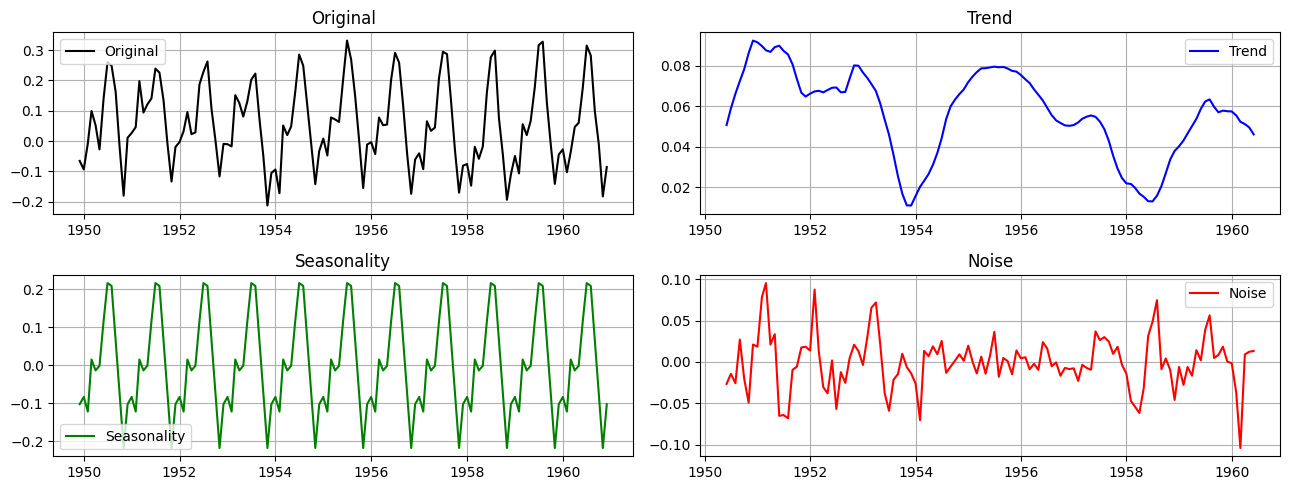

Statistic : -3.162907991300869
P-Value : 0.022234630001243157
No of Lags : 13
Number Of Observation : 119
Critical Values : {'1%': -3.4865346059036564, '5%': -2.8861509858476264, '10%': -2.579896092790057}
AIC : -436.63269481747034


In [67]:
# Log + Moving Average Diffrencing 
moving_avg = pd.Series(df['log']).rolling(window=12).mean()
df['log_mov_diff'] = df['log'].values - moving_avg

# Seasonality 
raw_data_seasonality = sd(df['log_mov_diff'].dropna(), model='addictive')
raw_data_seasonality.plot()

Original = df['log_mov_diff']
Trend = raw_data_seasonality.trend
Noise = raw_data_seasonality.resid
Seasonality = raw_data_seasonality.seasonal

fig, axes = plt.subplots(2, 2, figsize=(13, 5))

axes[0,0].plot(Original, label='Original', color='black')
axes[0,0].grid(True)
axes[0,0].set_title('Original')
axes[0,0].legend(loc='best')

axes[0,1].plot(Trend, label='Trend', color='blue')
axes[0,1].grid(True)
axes[0,1].set_title('Trend')
axes[0,1].legend(loc='best')

axes[1,0].plot(Seasonality, label='Seasonality', color='green')
axes[1,0].grid(True)
axes[1,0].set_title('Seasonality')
axes[1,0].legend(loc='best')

axes[1,1].plot(Noise, label='Noise', color='red')
axes[1,1].grid(True)
axes[1,1].set_title('Noise')
axes[1,1].legend(loc='best')

plt.tight_layout()

plt.show()

# Test ADF
Names = ['Statistic', 'P-Value', 'No of Lags', 'Number Of Observation', 'Critical Values', 'AIC']

raw_adf = adf(df['log_mov_diff'].dropna())

for name, result in zip(Names, raw_adf):
    print(f'{name} : {result}')


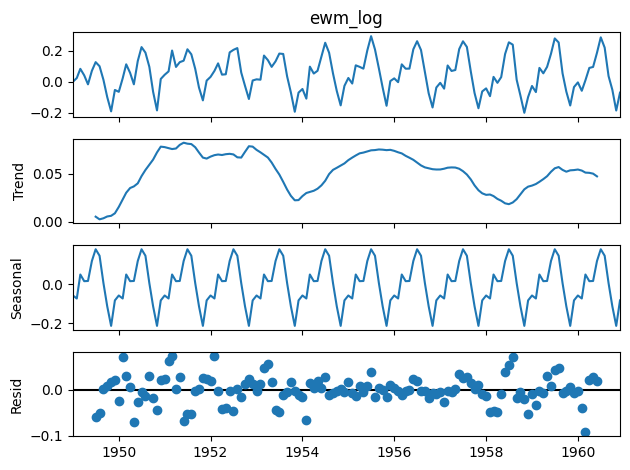

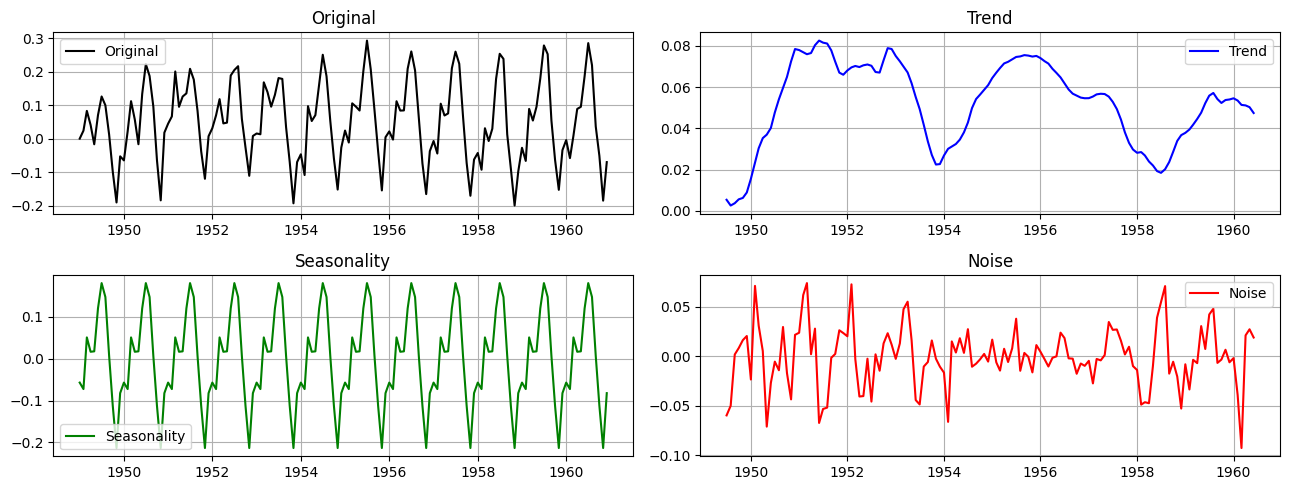

Statistic : -3.3105424543208746
P-Value : 0.01441375329697869
No of Lags : 13
Number Of Observation : 130
Critical Values : {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
AIC : -486.11770579662254


In [68]:
ema = pd.Series(df['log']).ewm(span=12).mean()
df['ewm_log'] = df['log'] - ema

# Seasonality 
raw_data_seasonality = sd(df['ewm_log'].dropna(), model='addictive')
raw_data_seasonality.plot()

Original = df['ewm_log']
Trend = raw_data_seasonality.trend
Noise = raw_data_seasonality.resid
Seasonality = raw_data_seasonality.seasonal

fig, axes = plt.subplots(2, 2, figsize=(13, 5))

axes[0,0].plot(Original, label='Original', color='black')
axes[0,0].grid(True)
axes[0,0].set_title('Original')
axes[0,0].legend(loc='best')

axes[0,1].plot(Trend, label='Trend', color='blue')
axes[0,1].grid(True)
axes[0,1].set_title('Trend')
axes[0,1].legend(loc='best')

axes[1,0].plot(Seasonality, label='Seasonality', color='green')
axes[1,0].grid(True)
axes[1,0].set_title('Seasonality')
axes[1,0].legend(loc='best')

axes[1,1].plot(Noise, label='Noise', color='red')
axes[1,1].grid(True)
axes[1,1].set_title('Noise')
axes[1,1].legend(loc='best')

plt.tight_layout()

plt.show()

# Test ADF
Names = ['Statistic', 'P-Value', 'No of Lags', 'Number Of Observation', 'Critical Values', 'AIC']

raw_adf = adf(df['ewm_log'].dropna())

for name, result in zip(Names, raw_adf):
    print(f'{name} : {result}')


# 2 Arima

In [96]:
# Data
data = pd.read_csv(r"E:\DATA FOR TEST\AirPassengers.csv",
                  index_col='Month',
                  parse_dates=['Month'],
                  date_format='%Y-%m')
df = copy.deepcopy(data)

# Basic HPO
train_size = int(len(df)*0.8)
train = np.log(df['#Passengers'][:train_size])
test = np.log(df['#Passengers'][train_size:])

p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

best_rmse, best_order = np.inf, None

for p in p_values:
    for d in d_values:
        for q in q_values:
            order = (p,d, q)
            try:
                model = ARIMA(train, order = order)
                model_fit = model.fit()

                predict = model_fit.forecast(steps=len(test))

                rmse_result = rmse(test, predict) 

                if rmse_result < best_rmse:
                    best_rmse = rmse_result
                    best_order = order
            except:
                continue

print(best_order, best_rmse)

(2, 1, 1) 0.18145376199034802


In [91]:
# Walking Forward Method
# Basic HPO
train_size = int(len(df)*0.8)
train = df['#Passengers'][:train_size]
test = df['#Passengers'][train_size:]

p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

best_rmse, best_order = np.inf, None

for p in p_values:
    for d in d_values:
        for q in q_values:
            order = (p,d, q)
            try:
                history = list(train)
                predictions = []
                for t in range(len(test)):
                    model = ARIMA(history, order = order)
                    model_fit = model.fit()
    
                    predict = model_fit.forecast(steps=1)[0]
                    predictions.append(predict)
    
                    history.append(test.iloc[t])
                rmse_result = rmse(test, predictions)

                if rmse_result < best_rmse:
                    best_rmse = rmse_result
                    best_order = order
                    
            except:
                continue

print(best_order, best_rmse)

(2, 1, 1) 44.218371833774874


In [101]:
# Arima Model
history = list(train)
predictions = []
for t in range(len(test)):
    model = ARIMA(history, order = (2, 1, 1))
    model_fit = model.fit()
    prediction = model_fit.forecast()[0]
    predictions.append(prediction)
    history.append(test.iloc[t])

result_rmse = rmse(test.values, predictions)
print('result_rmse: ', result_rmse)

# Visulization
plt.plot(test.values, color='red', label='Actual')
plt.plot(predictions, color='blue', label='Prediction')
plt.show()

result_rmse:  0.09998221906665214


# 3 FaceBook Prophet

In [122]:
# Data
data = pd.read_csv(r"E:\DATA FOR TEST\AirPassengers.csv")
df = copy.deepcopy(data)

df['Month'] = pd.to_datetime(df['Month'])
df = df.rename(columns={
    'Month':'ds',
    '#Passengers':'y'
})

df['y_orig'] = df['y'].copy()
df['y'] = np.log(df['y'])

02:54:37 - cmdstanpy - INFO - Chain [1] start processing
02:54:37 - cmdstanpy - INFO - Chain [1] done processing


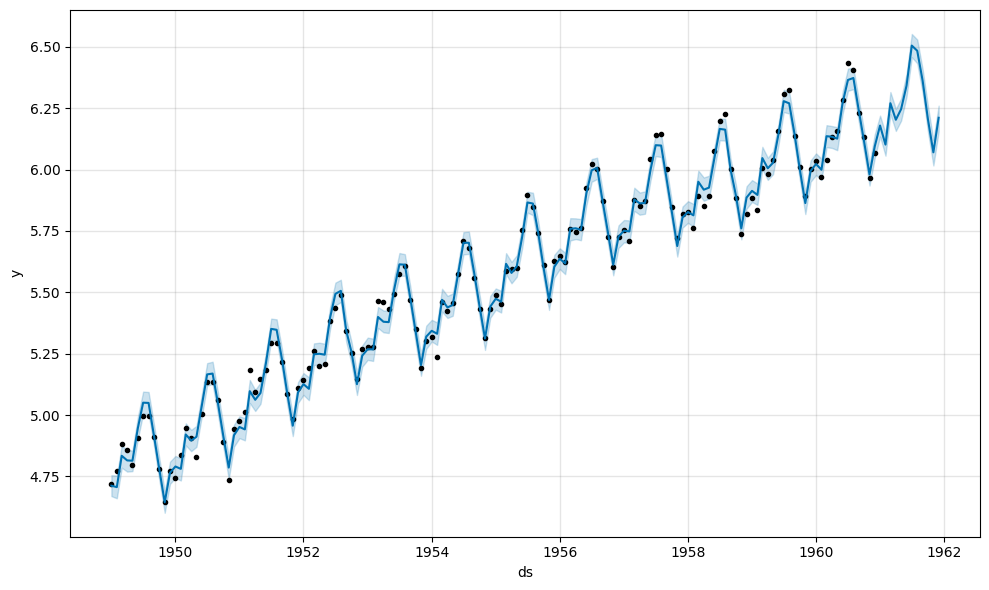

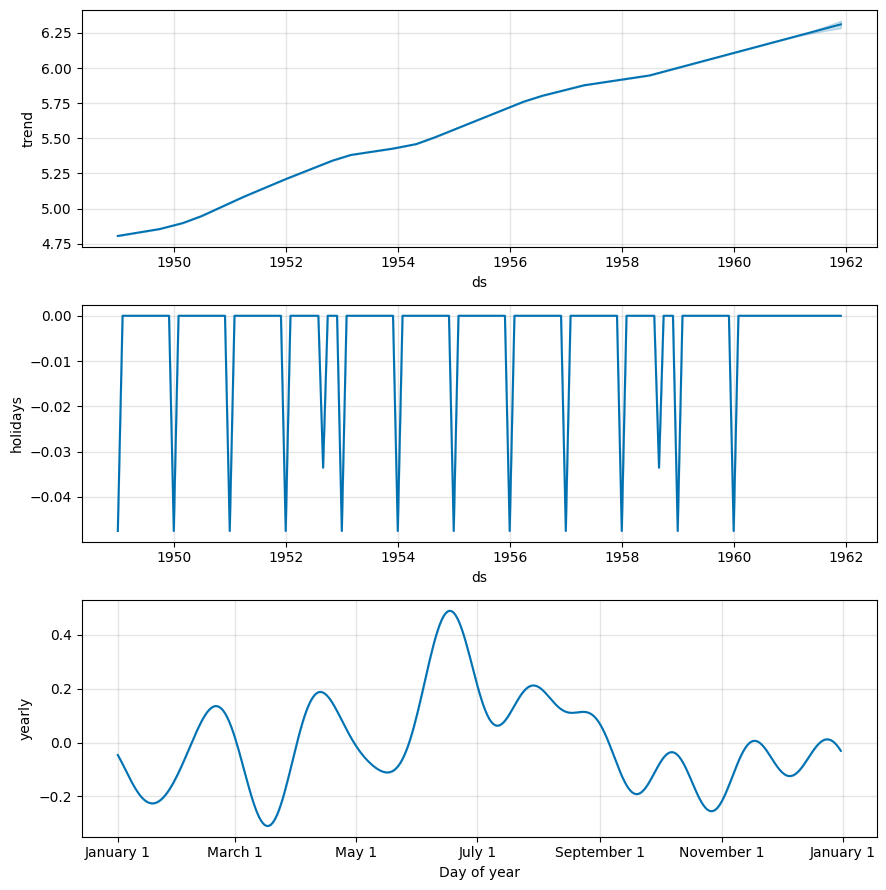

In [127]:
# Prophet Model
model = Prophet()
model.add_country_holidays(country_name='US')
model_fit = model.fit(df)

future_data = model_fit.make_future_dataframe(periods=12, freq='M')
prediction = model_fit.predict(future_data)

# Visulization
model.plot(prediction);
model.plot_components(prediction);

In [130]:
# Plot By Plotly
Original_data = pd.DataFrame(prediction[['ds', 'yhat', 'yhat_upper', 'yhat_lower']].copy())

Actual = go.Scatter(
    y=df['y_orig'],
    name='Actual',
    line=dict(color='black')
)

Predicted = go.Scatter(
    y=np.exp(prediction['yhat']),
    name='Actual',
    line=dict(color='blue')
)

Upper_Limit = go.Scatter(
    y=np.exp(prediction['yhat_upper']),
    name='Upper Limit',
    line=dict(color='Red')
)

Lower_Limit = go.Scatter(
    y=np.exp(prediction['yhat_lower']),
    name='Lower Limit',
    line=dict(color='green')
)

fig = go.plot(data[])
fig.plot();

py.plot([Actual, Predicted, Upper_Limit, Lower_Limit]);

'temp-plot.html'

# 4 Multivariate Facebook Prophet

22:35:47 - cmdstanpy - INFO - Chain [1] start processing
22:35:47 - cmdstanpy - INFO - Chain [1] done processing


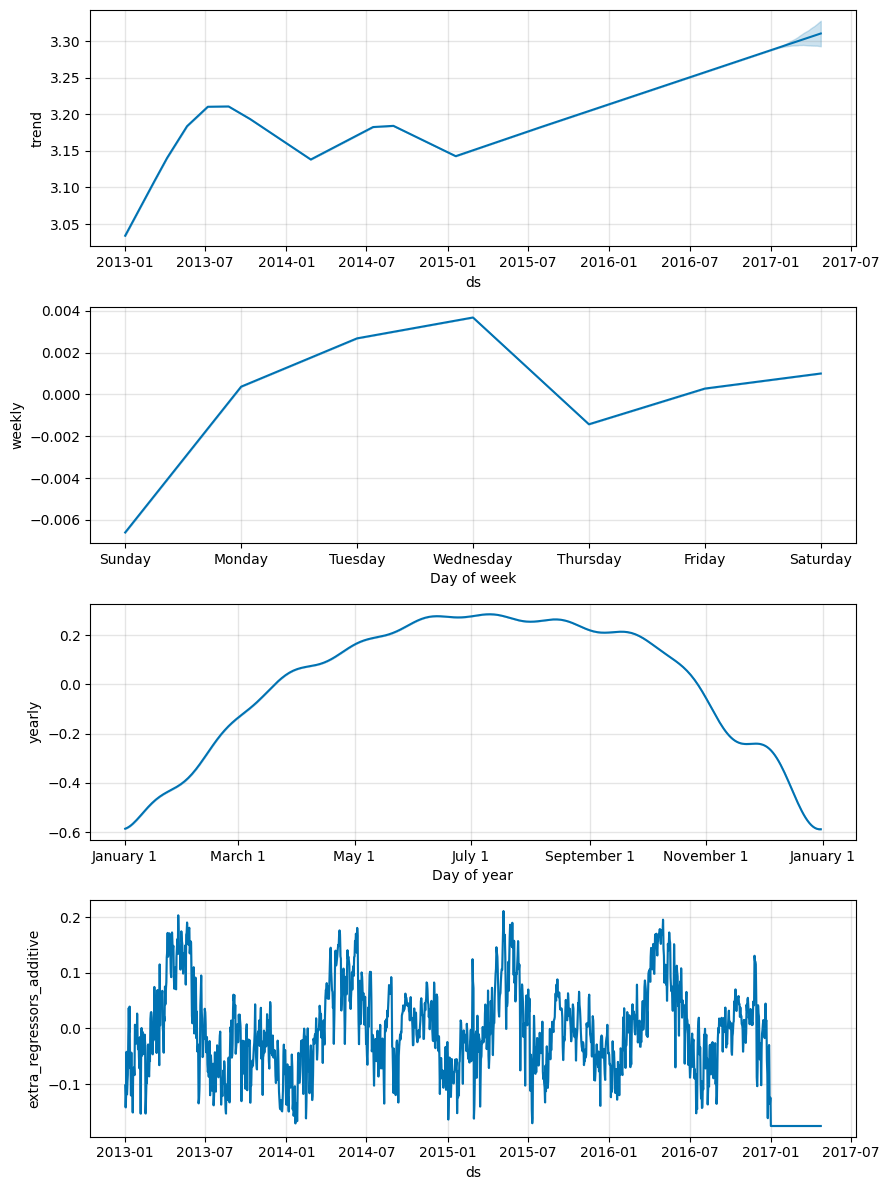

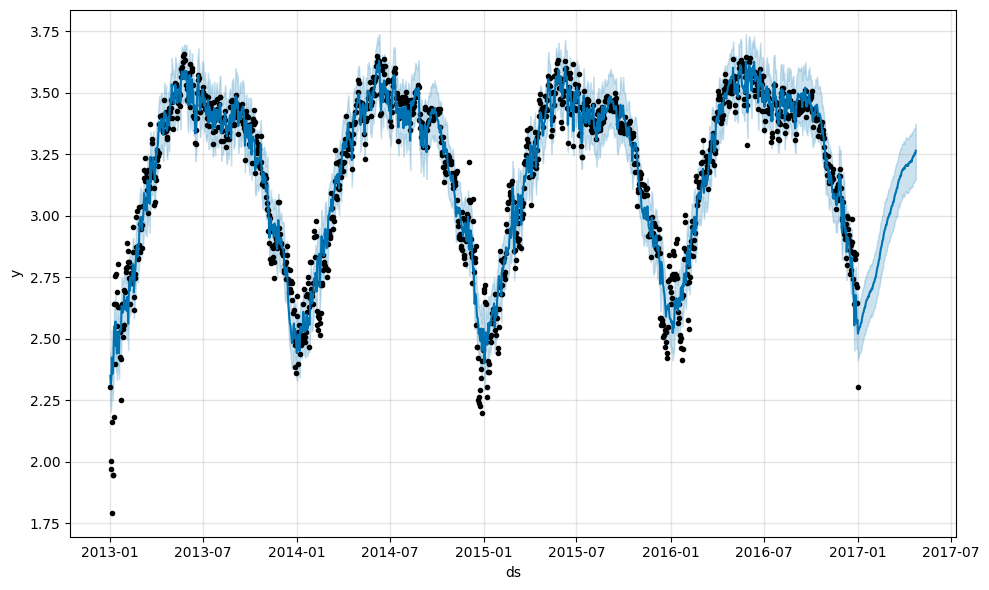

In [30]:
# Data 
# for Training Data
data_train = pd.read_csv(r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 7 Time Series Analysis\Resources\drive-download-20260225T095330Z-1-001\Multi Variate Forecasting\DailyDelhiClimateTrain.csv")
df = copy.deepcopy(data_train)
df['date'] = pd.to_datetime(df['date'], dayfirst=True) 
df = df.rename(columns={
    'date':'ds',
    'meantemp':'y'
})

df['y_orig'] = df['y']
df['y'] = np.log(df['y'])

model = Prophet()
model.add_regressor('humidity')
model.add_regressor('wind_speed')
model.add_regressor('meanpressure')

model_fit = model.fit(df)
future_data = model_fit.make_future_dataframe(periods=113, freq='D')
future_data = future_data.merge(df[['ds', 'humidity', 'wind_speed', 'meanpressure']], on='ds', how='left').ffill()

prediction = model_fit.predict(future_data)

model.plot_components(prediction);
model.plot(prediction);

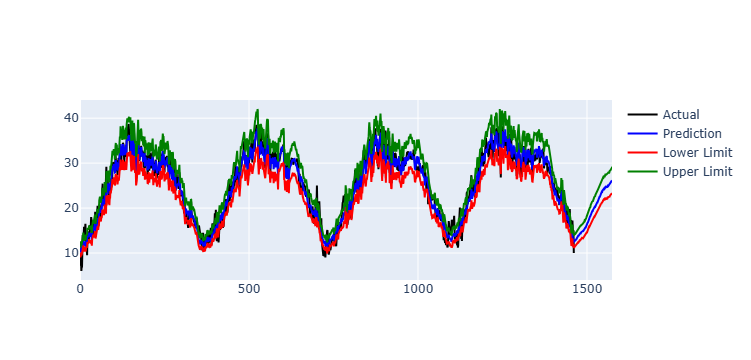

'temp-plot.html'

In [37]:
# Plot By Plotly
Actual = go.Scatter(y=df['y_orig'], name='Actual', line=dict(color='black'))
Prediction = go.Scatter(y=np.exp(prediction['yhat']), name = 'Prediction', line=dict(color='blue'))
Lower_Limit = go.Scatter(y=np.exp(prediction['yhat_lower']), name = 'Lower Limit', line=dict(color='red'))
Upper_Limit = go.Scatter(y=np.exp(prediction['yhat_upper']), name='Upper Limit', line=dict(color='green'))

fig = go.Figure([Actual, Prediction, Lower_Limit, Upper_Limit])
fig.show();
py.plot([Actual, Prediction, Lower_Limit, Upper_Limit])

# 5 Arima Model

Data Null Values:

 utc_timestamp          0
IT_load_new            0
IT_solar_generation    0
dtype: int64
Data Describe :

         IT_load_new  IT_solar_generation
count   8784.000000          8784.000000
mean   32257.230988          2049.831853
std     7258.900376          2845.846870
min    16716.000000             0.000000
25%    25944.500000             0.000000
50%    31654.500000            68.000000
75%    38637.250000          3923.500000
max    48986.000000         15824.000000


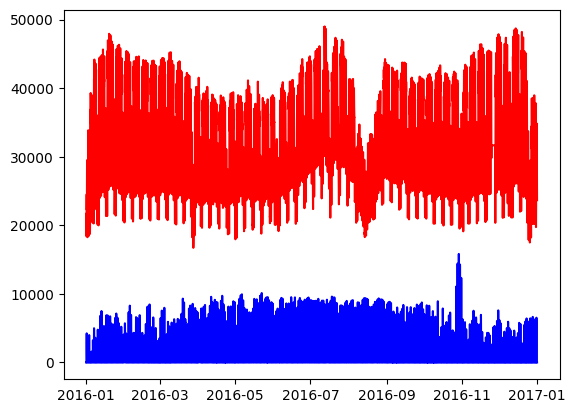

,utc_timestamp,IT_load_new,IT_solar_generation
0,2016-01-01 00:00:00+00:00,21665.0,1
1,2016-01-01 01:00:00+00:00,20260.0,0
2,2016-01-01 02:00:00+00:00,19056.0,0
3,2016-01-01 03:00:00+00:00,18407.0,0
4,2016-01-01 04:00:00+00:00,18425.0,0


In [40]:
data = pd.read_csv(r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 7 Time Series Analysis\Resources\drive-download-20260225T095330Z-1-001\Project 1 - ARIMA\TimeSeries_TotalSolarGen_and_Load_IT_2016.csv")
df = copy.deepcopy(data)

# Convert UTC Time Stamp in Data time Formate
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])

# Fill Null Values in Load Of Electricity
df['IT_load_new'] = df['IT_load_new'].fillna(df['IT_load_new'].median())

# Data Null Values
print('Data Null Values:\n\n', df.isna().sum())

# Data Describe
print('Data Describe :\n\n', df.describe())

# Plot Load And Generation ALong With Timestamp
plt.plot(df['utc_timestamp'], df['IT_load_new'], label='Load', color='red')
plt.plot(df['utc_timestamp'], df['IT_solar_generation'], label='Generation', color='blue')
plt.show()

df.head()


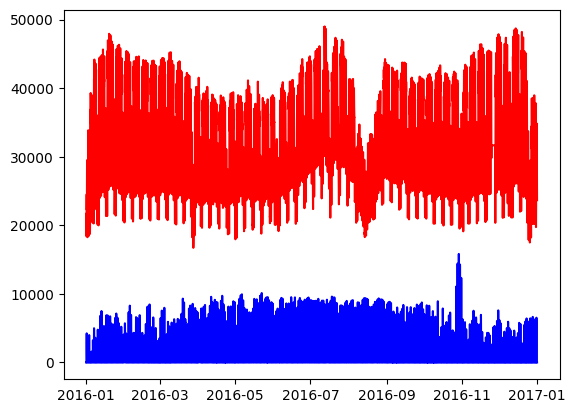